# Simplex method benchmarks

In [187]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import sys
# sys.path.append('.')
# sys.path.append('./DynaMix/')

plt.rcParams["font.family"] = "Helvetica"


from scipy.stats import norm
def err_from_corr(corr, pvalue):
    z_obs = np.arctanh(corr)
    z_stat = abs(norm.ppf(pvalue / 2))
    sd_z = abs(z_obs) / z_stat if z_stat != 0 else np.nan
    sd_r = sd_z * (1 - corr**2)
    return sd_r

# Lyapunov exponent calculation

In [2]:
import sys
## add the path to the project
sys.path.append('..')

from models.parrot import SimplexForecaster, context_parroting_forecast


In [65]:
import torch
from chronos import BaseChronosPipeline, ChronosPipeline, ChronosBoltPipeline

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-t5-base",  # use "amazon/chronos-bolt-small" for the corresponding Chronos-Bolt model
    #"amazon/chronos-bolt-base",
    #device_map="cuda",  # use "cpu" for CPU inference
    device_map="mps",
    torch_dtype=torch.bfloat16,
)

In [3]:
import sys
# sys.path.append('.')
sys.path.append('./DynaMix/')

import torch
# from src.model.dynamix import DynaMix
from src.model.forecaster import DynaMixForecaster
# from src.metrics.metrics import geometrical_misalignment, temporal_misalignment, MASE
# from src.utilities.plotting_eval import plot_3D_attractor, plot_2D_attractor, plot_TS_forecast
from src.utilities.utilities import load_hf_model

# Load the pre-trained model
model = load_hf_model("dynamix-3d-alrnn-v1.0")
model.eval() # Set model to evaluation mode
forecaster = DynaMixForecaster(model) # Initialize the forecaster

/Users/william/program_repos/parroting/benchmark/DynaMix/src/model/dynamix.py:95: RuntimeWarning: divide by zero encountered in matmul
  K = R.T @ R / M + np.eye(M)
/Users/william/program_repos/parroting/benchmark/DynaMix/src/model/dynamix.py:95: RuntimeWarning: overflow encountered in matmul
  K = R.T @ R / M + np.eye(M)
/Users/william/program_repos/parroting/benchmark/DynaMix/src/model/dynamix.py:95: RuntimeWarning: invalid value encountered in matmul
  K = R.T @ R / M + np.eye(M)


In [15]:
import glob
from dysts.analysis import max_lyapunov_exponent_rosenstein, max_lyapunov_exponent_rosenstein_multivariate, gp_dim
from dysts.metrics import estimate_kl_divergence


# results_path = "../analysis/Chronos_statistics/"
# results_path = "../analysis/dynamix_statistics/"
results_path = "../analysis/parrot_statistics/"
CHECK_EXISTING = True


forecast_length = 300
forecast_length = 10000
context_lengths = np.unique(np.logspace(np.log10(forecast_length), np.log10(4000), 10).astype(int))



if CHECK_EXISTING:
    all_lyap = np.load(results_path + f'all_lyap_vary_context_horizon_{forecast_length}.npy', allow_pickle=True).tolist()
    all_cdim = np.load(results_path + f'all_cdim_vary_context_horizon_{forecast_length}.npy', allow_pickle=True).tolist()
    all_kl_dist = np.load(results_path + f'all_kl_dist_vary_context_horizon_{forecast_length}.npy', allow_pickle=True).tolist()
else:
    all_lyap = list()
    all_cdim = list()
    all_kl_dist = list()

In [18]:
import glob
from dysts.analysis import max_lyapunov_exponent_rosenstein, max_lyapunov_exponent_rosenstein_multivariate, gp_dim
from dysts.metrics import estimate_kl_divergence


# results_path = "../analysis/Chronos_statistics/"
# results_path = "../analysis/dynamix_statistics/"
results_path = "../analysis/parrot_statistics/"
CHECK_EXISTING = True


forecast_length = 300
forecast_length = 10000
context_lengths = np.unique(np.logspace(np.log10(forecast_length), np.log10(4000), 10).astype(int))



if CHECK_EXISTING:
    all_lyap = np.load(results_path + f'all_lyap_vary_context_horizon_{forecast_length}.npy', allow_pickle=True).tolist()
    all_cdim = np.load(results_path + f'all_cdim_vary_context_horizon_{forecast_length}.npy', allow_pickle=True).tolist()
    all_kl_dist = np.load(results_path + f'all_kl_dist_vary_context_horizon_{forecast_length}.npy', allow_pickle=True).tolist()
    seen_ind = min(len(all_lyap), len(all_cdim), len(all_kl_dist))
else:
    all_lyap = list()
    all_cdim = list()
    all_kl_dist = list()

for sys_ind, trajectory in enumerate(sorted(glob.glob("../data/long_trajectories/*.npy"))):
    equation_name = trajectory.split("/")[-1].split(".")[0]
    print(equation_name, flush=True)
    
    if CHECK_EXISTING:
        if sys_ind < seen_ind:
            continue
    
    traj = np.load(trajectory, allow_pickle=True)
    traj = (traj - np.mean(traj, axis=0)) / np.std(traj, axis=0)

    try:
        
        all_cdim_inner = []
        all_kl_dist_inner = []
        all_lyap_inner = []
        for context_length in context_lengths:
            traj_context = traj[:context_length, :]
            traj_true = traj[context_length:context_length+forecast_length, :]



            traj_pred = list()
            for mode in range(traj_context.shape[1]):
                traj_pred_mode = context_parroting_forecast(traj_context[:, mode], forecast_total_length=forecast_length)[2]
                traj_pred.append(traj_pred_mode)
            traj_pred = np.array(traj_pred).T

            # traj_pred = list()
            # for mode in range(traj_context.shape[1]):
            #     model = SimplexForecaster()
            #     model.fit(traj_context[:, mode])
            #     traj_pred_mode = model.forecast(forecast_length)
            #     traj_pred.append(traj_pred_mode)
            # traj_pred = np.array(traj_pred).T


            # traj_pred = list()
            # for mode in range(traj_context.shape[1]):
            #     forecast = pipeline.predict(
            #         inputs=torch.tensor(traj_context[:, mode]),
            #         prediction_length=forecast_length,
            #         num_samples=20,
            #         limit_prediction_length=False,
            #         )
            #     traj_pred_mode = np.mean(forecast[0, :, :].detach().numpy(), axis=0)
            #     traj_pred.append(traj_pred_mode)
            # traj_pred = np.array(traj_pred).T


            # context_traj_tensor  = torch.tensor(traj_context)
            # with torch.no_grad(): 
            #     reconstruction = forecaster.forecast(
            #         context=context_traj_tensor,
            #         horizon=forecast_length, # Match the horizon of the ground truth
            #         standardize=True,
            #     )
            # traj_pred = reconstruction.detach().numpy()

            
            kl_dist = estimate_kl_divergence(traj_true, traj_pred)
            if np.isinf(kl_dist): kl_dist = np.nan
            
            
            cdim_true = gp_dim(traj_true)
            cdim_pred = gp_dim(traj_pred)
            cdim = np.array([cdim_pred, cdim_true])

            lyap_true = max_lyapunov_exponent_rosenstein(traj_true)
            if np.isinf(lyap_true): lyap_true = 0
            lyap_pred = max_lyapunov_exponent_rosenstein(traj_pred)
            if np.isinf(lyap_pred): lyap_pred = 0
            lyap = np.array([lyap_pred, lyap_true])


            all_cdim_inner.append(cdim)
            all_kl_dist_inner.append(kl_dist)
            all_lyap_inner.append(lyap)

        all_cdim.append(all_cdim_inner)
        all_kl_dist.append(all_kl_dist_inner)
        all_lyap.append(all_lyap_inner)

        np.array(all_cdim).dump(results_path + f'/all_cdim_vary_context_horizon_{forecast_length}.npy')
        np.array(all_kl_dist).dump(results_path + f'/all_kl_dist_vary_context_horizon_{forecast_length}.npy')
        np.array(all_lyap).dump(results_path + f'/all_lyap_vary_context_horizon_{forecast_length}.npy')


    except Exception as e:
        print(e)
        print(f"Skipping {equation_name}", flush=True)
        continue


Aizawa
AnishchenkoAstakhov
Arneodo
ArnoldBeltramiChildress
ArnoldWeb
AtmosphericRegime
BeerRNN
BelousovZhabotinsky
BickleyJet
Blasius
BlinkingRotlet
BlinkingVortex
Bouali
Bouali2
BurkeShaw
CaTwoPlus
CaTwoPlusQuasiperiodic
CellCycle
CellularNeuralNetwork
Chen
ChenLee
Chua
CircadianRhythm
CoevolvingPredatorPrey
Colpitts
Coullet
Dadras


/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/scipy/stats/_covariance.py:633: RuntimeWarning: divide by zero encountered in matmul
  return x @ self._LP
/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/scipy/stats/_covariance.py:633: RuntimeWarning: overflow encountered in matmul
  return x @ self._LP
/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/scipy/stats/_covariance.py:633: RuntimeWarning: invalid value encountered in matmul
  return x @ self._LP


DequanLi
DoubleGyre
DoublePendulum
Duffing
ExcitableCell
Finance
ForcedBrusselator
ForcedFitzHughNagumo
ForcedVanDerPol
GenesioTesi
GlycolyticOscillation
GuckenheimerHolmes
Hadley
Halvorsen
HastingsPowell
HenonHeiles
HindmarshRose
Hopfield
HyperBao
HyperCai
HyperJha
HyperLorenz
HyperPang
HyperQi
HyperRossler
HyperWang
HyperXu
HyperYan
HyperYangChen
IkedaDelay
InteriorSquirmer
IsothermalChemical
ItikBanksTumor
JerkCircuit
KawczynskiStrizhak
Laser
LidDrivenCavityFlow
LiuChen
Lorenz
Lorenz84
Lorenz96
LorenzBounded
LorenzCoupled
LorenzStenflo
LuChen
LuChenCheng
MacArthur
MackeyGlass
MooreSpiegel
MultiChua
NewtonLiepnik
NoseHoover
NuclearQuadrupole
OscillatingFlow
PanXuZhou
index -1 is out of bounds for axis 0 with size 0
Skipping PanXuZhou
PehlivanWei
PiecewiseCircuit
Qi
QiChen
RabinovichFabrikant
RayleighBenard
RikitakeDynamo
Rossler
Rucklidge
Sakarya
SaltonSea
SanUmSrisuchinwong
ScrollDelay
ShimizuMorioka
SprottA
SprottB
SprottC
SprottD
SprottDelay
SprottE
SprottF
SprottG
SprottH
SprottI

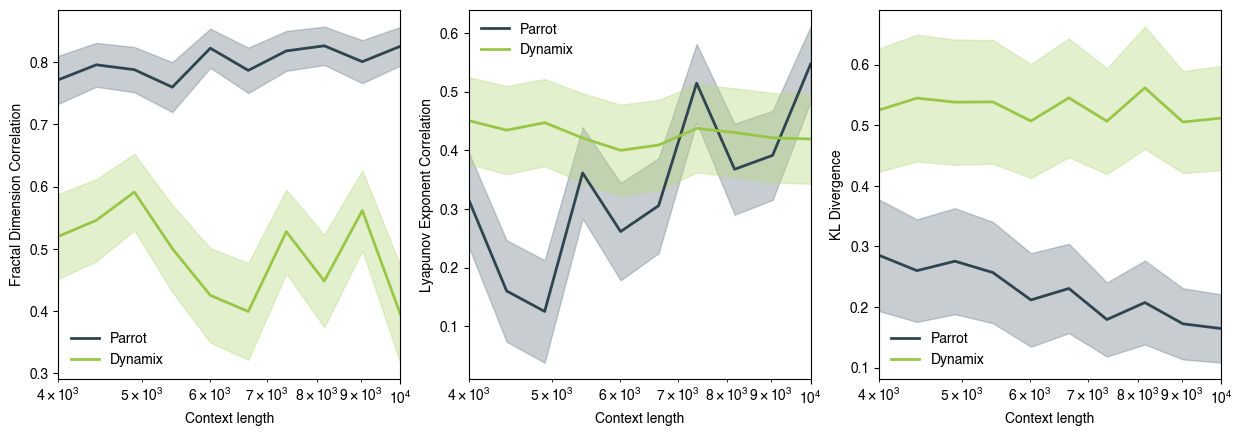

In [ ]:
import degas as dg
from scipy.stats import pearsonr, spearmanr

# model_names = ["parrot", "dynamix", "simplex", "Chronos"]
# colors = [dg.red, dg.blue, dg.turquoise, dg.orange][:len(model_names)]
model_names = ["parrot", "dynamix"]
colors = [dg.blue]

import degas as dg


forecast_length = 10000
context_lengths = np.unique(np.logspace(np.log10(forecast_length), np.log10(4000), 10).astype(int))


colors = np.array([
        np.array([46, 69, 81]),
        np.array([152, 199, 71]),
    ]) / 255


plt.figure(figsize=(15, 4.8))

plt.subplot(1, 3, 1)
for model_name, color in zip(model_names, colors):
    results_path = f"../analysis/{model_name}_statistics/"
    all_cdim = np.load(results_path + f'all_cdim_vary_context_horizon_{forecast_length}.npy', allow_pickle=True)

    all_cdim = np.array(all_cdim)
    all_cdim_transposed = all_cdim.transpose(1, 0, 2)
    
    corrs = [pearsonr(cdim_pair[:, 0], cdim_pair[:, 1])[0] for cdim_pair in all_cdim_transposed]
    corr_errs = [err_from_corr(corr, pearsonr(cdim_pair[:, 0], cdim_pair[:, 1])[1]) for corr, cdim_pair in zip(corrs, all_cdim_transposed)]
    # plt.semilogx(
    #     context_lengths, [spearmanr(lyap_pair[:, 0], lyap_pair[:, 1])[0] for lyap_pair in all_lyap_transposed], label=model_name.capitalize()
    # )
    corrs = [pearsonr(cdim_pair[:, 0], cdim_pair[:, 1])[0] for cdim_pair in all_cdim_transposed]
    corr_errs = [err_from_corr(corr, pearsonr(cdim_pair[:, 0], cdim_pair[:, 1])[1]) for corr, cdim_pair in zip(corrs, all_cdim_transposed)]
    plt.semilogx()
    dg.plot_err(np.array(corrs), np.array(corr_errs), x=context_lengths, label=model_name.capitalize(), color=color, linewidth=2)

plt.xlim(context_lengths[0], context_lengths[-1])
plt.legend(frameon=False)
plt.xlabel("Context length")
plt.ylabel("Fractal Dimension Correlation")


plt.subplot(1, 3, 2)
for model_name, color in zip(model_names, colors):
    results_path = f"../analysis/{model_name}_statistics/"
    all_lyap = np.load(results_path + f'/all_lyap_vary_context_horizon_{forecast_length}.npy', allow_pickle=True)

    all_lyap = np.array(all_lyap)
    all_lyap_transposed = all_lyap.transpose(1, 0, 2)
    ## Capitalize the first letter of the model name
    corrs = [pearsonr(lyap_pair[:, 0], lyap_pair[:, 1])[0] for lyap_pair in all_lyap_transposed]
    corr_errs = [err_from_corr(corr, pearsonr(lyap_pair[:, 0], lyap_pair[:, 1])[1]) for corr, lyap_pair in zip(corrs, all_lyap_transposed)]
    # plt.semilogx(
    #     context_lengths, [spearmanr(lyap_pair[:, 0], lyap_pair[:, 1])[0] for lyap_pair in all_lyap_transposed], label=model_name.capitalize()
    # )
    plt.semilogx()
    dg.plot_err(np.array(corrs), np.array(corr_errs), x=context_lengths, label=model_name.capitalize(), color=color, linewidth=2)

plt.xlim(context_lengths[0], context_lengths[-1])
plt.legend(frameon=False)
plt.xlabel("Context length")
plt.ylabel("Lyapunov Exponent Correlation")


plt.subplot(1, 3, 3)
for model_name, color in zip(model_names, colors):
    results_path = f"../analysis/{model_name}_statistics/"
    all_kl_dist = np.load(results_path + f'/all_kl_dist_vary_context_horizon_{forecast_length}.npy', allow_pickle=True)

    all_kl_dist = np.array(all_kl_dist)

    ## Capitalize the first letter of the model name
    # plt.semilogx(
    #     context_lengths, np.mean(all_kl_dist, axis=0), label=model_name.capitalize()
    # )
    plt.semilogx()
    dg.plot_err(
        np.mean(all_kl_dist, axis=0), np.std(all_kl_dist, axis=0) / np.sqrt(len(all_kl_dist)),
         x=context_lengths, label=model_name.capitalize(), color=color, linewidth=2
    )
plt.xlim(context_lengths[0], context_lengths[-1])
plt.legend(frameon=False)
plt.xlabel("Context length")
plt.ylabel("KL Divergence")


# dg.better_savefig(f"../analysis/vary_context_f{forecast_length}.pdf", dpi=300, transparent=True)


In [181]:
results_path = f"../analysis/{model_name}_statistics/"
all_kl_dist = np.load(results_path + '/all_kl_dist_vary_context.npy', allow_pickle=True)

Text(0, 0.5, 'KL Divergence')

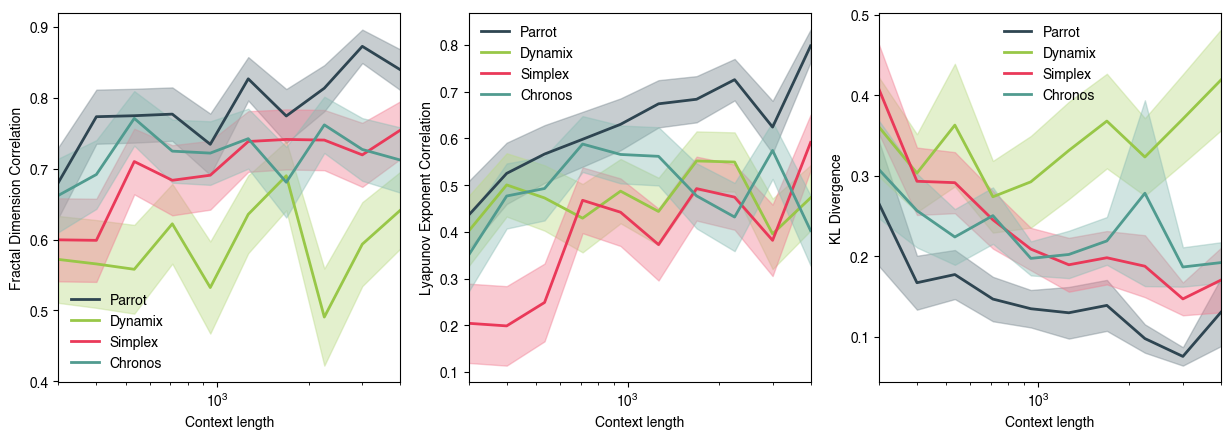

In [ ]:
from scipy.stats import pearsonr, spearmanr

model_names = ["parrot", "dynamix", "simplex", "Chronos"]
colors = [dg.red, dg.blue, dg.turquoise, dg.orange][:len(model_names)]
# model_names = ["parrot", "dynamix",  "simplex"]

import degas as dg


forecast_length = 300
context_lengths = np.unique(np.logspace(np.log10(forecast_length), np.log10(4000), 10).astype(int))


colors = np.array([
        np.array([46, 69, 81]),
        np.array([152, 199, 71]),
        np.array([234, 57, 89]),
        np.array([80, 155, 143]),
    ]) / 255

plt.figure(figsize=(15, 4.8))

plt.subplot(1, 3, 1)
for model_name, color in zip(model_names, colors):
    results_path = f"../analysis/{model_name}_statistics/"
    all_cdim = np.load(results_path + '/all_cdim_vary_context.npy', allow_pickle=True)

    all_cdim = np.array(all_cdim)
    all_cdim_transposed = all_cdim.transpose(1, 0, 2)
    
    corrs = [pearsonr(cdim_pair[:, 0], cdim_pair[:, 1])[0] for cdim_pair in all_cdim_transposed]
    corr_errs = [err_from_corr(corr, pearsonr(cdim_pair[:, 0], cdim_pair[:, 1])[1]) for corr, cdim_pair in zip(corrs, all_cdim_transposed)]
    # plt.semilogx(
    #     context_lengths, [spearmanr(lyap_pair[:, 0], lyap_pair[:, 1])[0] for lyap_pair in all_lyap_transposed], label=model_name.capitalize()
    # )
    corrs = [pearsonr(cdim_pair[:, 0], cdim_pair[:, 1])[0] for cdim_pair in all_cdim_transposed]
    corr_errs = [err_from_corr(corr, pearsonr(cdim_pair[:, 0], cdim_pair[:, 1])[1]) for corr, cdim_pair in zip(corrs, all_cdim_transposed)]
    plt.semilogx()
    dg.plot_err(np.array(corrs), np.array(corr_errs), x=context_lengths, label=model_name.capitalize(), color=color, linewidth=2)

plt.xlim(context_lengths[0], context_lengths[-1])
plt.legend(frameon=False)
plt.xlabel("Context length")
plt.ylabel("Fractal Dimension Correlation")


plt.subplot(1, 3, 2)
for model_name, color in zip(model_names, colors):
    results_path = f"../analysis/{model_name}_statistics/"
    all_lyap = np.load(results_path + '/all_lyap_vary_context.npy', allow_pickle=True)

    all_lyap = np.array(all_lyap)
    all_lyap_transposed = all_lyap.transpose(1, 0, 2)
    ## Capitalize the first letter of the model name
    corrs = [pearsonr(lyap_pair[:, 0], lyap_pair[:, 1])[0] for lyap_pair in all_lyap_transposed]
    corr_errs = [err_from_corr(corr, pearsonr(lyap_pair[:, 0], lyap_pair[:, 1])[1]) for corr, lyap_pair in zip(corrs, all_lyap_transposed)]
    # plt.semilogx(
    #     context_lengths, [spearmanr(lyap_pair[:, 0], lyap_pair[:, 1])[0] for lyap_pair in all_lyap_transposed], label=model_name.capitalize()
    # )
    plt.semilogx()
    dg.plot_err(np.array(corrs), np.array(corr_errs), x=context_lengths, label=model_name.capitalize(), color=color, linewidth=2)

plt.xlim(context_lengths[0], context_lengths[-1])
plt.legend(frameon=False)
plt.xlabel("Context length")
plt.ylabel("Lyapunov Exponent Correlation")


plt.subplot(1, 3, 3)
for model_name, color in zip(model_names, colors):
    results_path = f"../analysis/{model_name}_statistics/"
    all_kl_dist = np.load(results_path + '/all_kl_dist_vary_context.npy', allow_pickle=True)

    all_kl_dist = np.array(all_kl_dist)

    ## Capitalize the first letter of the model name
    # plt.semilogx(
    #     context_lengths, np.mean(all_kl_dist, axis=0), label=model_name.capitalize()
    # )
    plt.semilogx()
    dg.plot_err(
        np.mean(all_kl_dist, axis=0), np.std(all_kl_dist, axis=0) / np.sqrt(len(all_kl_dist)),
         x=context_lengths, label=model_name.capitalize(), color=color, linewidth=2
    )
plt.xlim(context_lengths[0], context_lengths[-1])
plt.legend(frameon=False)
plt.xlabel("Context length")
plt.ylabel("KL Divergence")


# dg.better_savefig("../analysis/vary_context.pdf", dpi=300, transparent=True)


<!-- # Check how Lyapunov exponents vary with integration time -->

# Sweep Lyapunov exponent integration timescales

In [188]:
from scipy.spatial.distance import cdist
def max_lyapunov_exponent_rosenstein_multivariate(
    data: np.ndarray,  # Shape: (n_timesteps, n_dimensions)
    lag: int | None = None,
    min_tsep: int | None = None,
    tau: float = 1,
    trajectory_len: int = 64,
    fit: str = "RANSAC",
    fit_offset: int = 0,
) -> float:
    """
    Multivariate version of Rosenstein's algorithm.
    """
    data = np.asarray(data, dtype="float32")
    n, d = data.shape  # n = timesteps, d = dimensions
    max_tsep_factor = 0.25

    # For multivariate data, we might need to estimate min_tsep differently
    # One approach: use the first dimension or average across dimensions
    if lag is None or min_tsep is None:
        # Use first dimension for frequency estimation
        f = np.fft.rfft(data[:, 0], n * 2 - 1)

    if min_tsep is None:
        mf = np.fft.rfftfreq(n * 2 - 1) * np.abs(f)
        mf = np.mean(mf[1:]) / np.sum(np.abs(f[1:]))
        min_tsep = int(np.ceil(1.0 / mf))
        if min_tsep > max_tsep_factor * n:
            min_tsep = int(max_tsep_factor * n)

    orbit = data  # Shape: (n_timesteps, n_dimensions)
    m = len(orbit)
    dists = cdist(orbit, orbit, metric="euclidean")

    # temporal separation constraint: mask out diagonal band
    # mask = np.abs(np.arange(m)[:, None] - np.arange(m)[None, :]) < min_tsep
    # dists[mask] = float("inf")
    mask = np.abs(np.arange(m)[:, None] - np.arange(m)[None, :]) <= min_tsep
    dists[mask] = float("inf")

    ntraj = m - trajectory_len + 1
    min_traj = min_tsep * 2 + 2

    if ntraj <= 0:
        raise ValueError(
            f"Not enough data points. Need {-ntraj + 1} additional data points to follow a complete trajectory."
        )
    if ntraj < min_traj:
        raise ValueError(
            f"Not enough data points. At least {min_traj} trajectories are required to find a valid neighbor for each orbit vector with min_tsep={min_tsep} but only {ntraj} could be created."
        )

    nb_idx = np.argmin(dists[:ntraj, :ntraj], axis=1)

    div_traj = np.zeros(trajectory_len, dtype=float)
    for k in range(trajectory_len):
        indices = (np.arange(ntraj) + k, nb_idx + k)
        # div_traj_k = dists[indices]

        eps = 1e-12
        div_traj_k = dists[indices]
        valid = np.isfinite(div_traj_k)
        div_traj_k = div_traj_k[valid]

        if len(div_traj_k) == 0:
            div_traj[k] = -np.inf
        else:
            div_traj[k] = np.mean(np.log(div_traj_k + eps))


    ks = np.arange(trajectory_len)
    finite = np.where(np.isfinite(div_traj))
    ks = ks[finite]
    div_traj = div_traj[finite]

    if len(ks) < 1:
        return -np.inf

    poly = np.polyfit(ks[fit_offset:], div_traj[fit_offset:], 1)

    le = poly[0] / tau
    return le

In [ ]:
import glob
import degas as dg
from scipy.stats import pearsonr, spearmanr

results_path = "../analysis/"

# model_names = ["parrot", "dynamix", "simplex", "Chronos"]
# colors = [dg.red, dg.blue, dg.turquoise, dg.orange][:len(model_names)]
model_names = ["parrot", "dynamix"]
colors = [dg.blue]

import degas as dg

context_length = 2000
forecast_length = 10000
lyapunov_timescales = np.unique(np.logspace(1, 3, 25).astype(int))

all_all_lyap = list()
all_all_lyap_dynamix = list()
all_all_lyap_parrot = list()

import dysts.flows as dfl
from dysts.systems import get_attractor_list
eq_names = sorted(get_attractor_list())[::-1]
# all_lyap_true, all_lyap_parrot, all_lyap_dynamix = list(), list(), list()
for sys_ind, equation_name in enumerate(eq_names):
    print(equation_name, flush=True)
    np.random.seed(0)
    eq = getattr(dfl, equation_name)()
    eq.ic += np.random.randn(len(eq.ic)) * 0.3
    traj = eq.make_trajectory(500 + context_length + forecast_length, standardize=True)[500:]
    traj_context = traj[:context_length, :]
    traj_true = traj[context_length:context_length+forecast_length, :]
    
    try:    

        traj_pred = list()
        for mode in range(traj_context.shape[1]):
            traj_pred_mode = context_parroting_forecast(traj_context[:, mode], forecast_total_length=forecast_length)[2]
            traj_pred.append(traj_pred_mode)
        traj_pred_parrot = np.array(traj_pred).T


        context_traj_tensor  = torch.tensor(traj_context)
        with torch.no_grad(): 
            reconstruction = forecaster.forecast(
                context=context_traj_tensor,
                horizon=forecast_length, # Match the horizon of the ground truth
                standardize=True,
            )
        traj_pred_dynamix = reconstruction.detach().numpy()


        all_lyap = list()
        for lyapunov_timescale in lyapunov_timescales:
            lyap = max_lyapunov_exponent_rosenstein_multivariate(traj_true, trajectory_len=lyapunov_timescale)
            all_lyap.append(lyap)
        

        all_lyap_dynamix = list()
        for lyapunov_timescale in lyapunov_timescales:
            lyap = max_lyapunov_exponent_rosenstein_multivariate(traj_pred_dynamix, trajectory_len=lyapunov_timescale)
            all_lyap_dynamix.append(lyap)
        

        all_lyap_parrot = list()
        for lyapunov_timescale in lyapunov_timescales:
            lyap = max_lyapunov_exponent_rosenstein_multivariate(traj_pred_parrot, trajectory_len=lyapunov_timescale)
            all_lyap_parrot.append(lyap)

        all_all_lyap.append(np.array(all_lyap))
        all_all_lyap_dynamix.append(np.array(all_lyap_dynamix))
        all_all_lyap_parrot.append(np.array(all_lyap_parrot))



    except Exception as e:
        print(e)
        print(f"Skipping {equation_name}", flush=True)
        continue

    np.array(all_all_lyap).dump(results_path + "all_all_lyap_sweeping_lyapunov2.npy") # Why are these files so large?
    np.array(all_all_lyap_dynamix).dump(results_path + "all_all_lyap_sweeping_lyapunov_dynamix2.npy")
    np.array(all_all_lyap_parrot).dump(results_path + "all_all_lyap_sweeping_lyapunov_parrot2.npy") 

all_all_lyap = np.array(all_all_lyap)
all_all_lyap_dynamix = np.array(all_all_lyap_dynamix)
all_all_lyap_parrot = np.array(all_all_lyap_parrot)


In [ ]:
## Runs got interrupted

all_all_lyap1 = np.load(results_path + "all_all_lyap_sweeping_lyapunov.npy", allow_pickle=True)
all_all_lyap_dynamix1 = np.load(results_path + "all_all_lyap_sweeping_lyapunov_dynamix.npy", allow_pickle=True)
all_all_lyap_parrot1 = np.load(results_path + "all_all_lyap_sweeping_lyapunov_parrot.npy", allow_pickle=True)


all_all_lyap2 = np.load(results_path + "all_all_lyap_sweeping_lyapunov2.npy", allow_pickle=True)
all_all_lyap_dynamix2 = np.load(results_path + "all_all_lyap_sweeping_lyapunov_dynamix2.npy", allow_pickle=True)
all_all_lyap_parrot2 = np.load(results_path + "all_all_lyap_sweeping_lyapunov_parrot2.npy", allow_pickle=True)

all_all_lyap = np.concatenate([all_all_lyap1, all_all_lyap2], axis=0)
all_all_lyap_dynamix = np.concatenate([all_all_lyap_dynamix1, all_all_lyap_dynamix2], axis=0)
all_all_lyap_parrot = np.concatenate([all_all_lyap_parrot1, all_all_lyap_parrot2], axis=0)

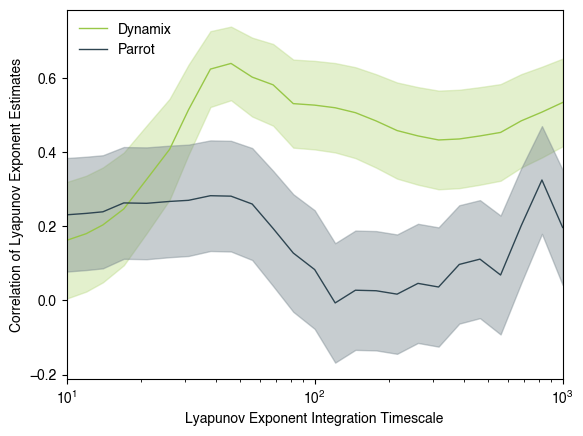

In [ ]:
from scipy.stats import pearsonr

all_corr_dynamix = list()
all_corr_err_dynamix = list()
all_corr_parrot = list()
all_corr_err_parrot = list()
for lyap_true, lyap_pred_dynamix, lyap_pred_parrot in zip(
                                                        all_all_lyap.T, 
                                                        all_all_lyap_dynamix.T, 
                                                        all_all_lyap_parrot.T
                                                        ):
    sel_inds = np.isfinite(lyap_pred_dynamix)
    corr_dynamix = pearsonr(lyap_true[sel_inds], lyap_pred_dynamix[sel_inds])[0]
    corr_err_dynamix = err_from_corr(corr_dynamix, pearsonr(lyap_true[sel_inds], lyap_pred_dynamix[sel_inds])[1])
    
    corr_parrot = pearsonr(lyap_true, lyap_pred_parrot)[0]
    corr_err_parrot = err_from_corr(corr_parrot, pearsonr(lyap_true, lyap_pred_parrot)[1])
    
    
    all_corr_dynamix.append(corr_dynamix)
    all_corr_err_dynamix.append(corr_err_dynamix)
    all_corr_parrot.append(corr_parrot)
    all_corr_err_parrot.append(corr_err_parrot)

all_corr_dynamix = np.array(all_corr_dynamix)
all_corr_err_dynamix = np.array(all_corr_err_dynamix)
all_corr_parrot = np.array(all_corr_parrot)
all_corr_err_parrot = np.array(all_corr_err_parrot)

colors = np.array([
        np.array([46, 69, 81]),
        np.array([152, 199, 71]),
    ]) / 255

plt.semilogx()
dg.plot_err(all_corr_dynamix, all_corr_err_dynamix, x=lyapunov_timescales, label="Dynamix", color=colors[1])
dg.plot_err(all_corr_parrot, all_corr_err_parrot, x=lyapunov_timescales, label="Parrot", color=colors[0])
plt.xlim(lyapunov_timescales[0], lyapunov_timescales[-1])
plt.xlabel("Lyapunov Exponent Integration Timescale")
plt.ylabel("Correlation of Lyapunov Exponent Estimates")
plt.legend(frameon=False)

# dg.better_savefig("../analysis/sweep_lyapunov_integration.pdf", dpi=300, transparent=True)
    